<a href="https://colab.research.google.com/github/RRADJon/TEMPO/blob/main/Training_NN_FractionUnbound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Batch Ligand Dataset

from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
ligand_df = pd.read_csv(file_name)
required_cols = ["smiles"]
optional_cols = ["name", "fu_true"]
missing_required = [c for c in required_cols if c not in ligand_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Add missing optional columns
if "name" not in ligand_df.columns:
    ligand_df["name"] = [f"ligand_{i}" for i in range(len(ligand_df))]

if "fu_true" not in ligand_df.columns:
    print("No fu_true column found — setting to 0 (prediction-only mode)")
    ligand_df["fu_true"] = 0.0

# Reorder columns
ligand_df = ligand_df[["name", "smiles", "fu_true"]]

print("Loaded dataset:")
display(ligand_df.head())

print(f"\nTotal ligands: {len(ligand_df)}")

Saving Fraction_Unbound_Dataset_test.csv to Fraction_Unbound_Dataset_test.csv
Loaded dataset:


,name,smiles,fu_true
0,triamcinolone,CC12CC(C3(C(C1CC(C2(C(=O)CO)O)O)CCC4=CC(=O)C=C...,0.68
1,triamterene,C1=CC=C(C=C1)C2=NC3=C(N=C(N=C3N=C2N)N)N,0.67
2,triflupromazine,CN(C)CCCN1C2=CC=CC=C2SC3=C1C=C(C=C3)C(F)(F)F,0.90
3,trihexyphenidyl,C1CCC(CC1)C(CCN2CCCCC2)(C3=CC=CC=C3)O,0.58
4,trimethoprim,COC1=CC(=CC(=C1OC)OC)CC2=CN=C(N=C2N)N,0.44



Total ligands: 6


In [ ]:
#@title Functions
def download_pdb(pdb_id):
    filename = f"{pdb_id}.pdb"
    if not os.path.exists(filename):
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        r = requests.get(url)
        with open(filename, "wb") as f:
            f.write(r.content)
    return filename

def load_pdb_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

#Functions Loop Function
import time
import requests

def predict_structure(protein_id, sequence, ligand_smiles):
    polymer_id = "A"  # must be <= 4 characters
    template_b64 = template_b64_map.get(protein_id)

    request_body = {
        "polymers": [
            {
                "id": polymer_id,
                "sequence": sequence,
                "molecule_type": "protein",
                "templates": [
                    {
                        "pdb": template_b64,
                        "chain_id": "A"
                    }
                ] if template_b64 else []
            }
        ],
        "ligands": [
            {
                "id": "L1",  # Ligand ID
                "smiles": ligand_smiles,
                "predict_affinity": True  # MUST be True to get scores
            }
        ]
    }

    response = requests.post(
        PUBLIC_URL,
        headers=headers,
        json=request_body
    )

    if response.status_code == 429:
        print("Rate limited. Sleeping 1 second...")
        time.sleep(1)
        return predict_structure(protein_id, sequence, ligand_smiles)

    if response.status_code != 200:
        raise Exception(response.text)

    return response.json()
#@title Batch Boltz Runner

def run_batch_predictions_df(protein_batch, ligand_df):

    all_results = []

    for _, row in ligand_df.iterrows():

        ligand_smiles = row["smiles"]
        ligand_name = row["name"]

        print("\n" + "="*50)
        print(f"Processing ligand: {ligand_name}")

        protein_results = run_batch_predictions(
            protein_batch=protein_batch,
            ligand_smiles=ligand_smiles
        )

        # Convert to dict
        result_dict = {
            "name": ligand_name,
            "smiles": ligand_smiles
        }

        for r in protein_results:
            pid = r["Protein ID"]

            result_dict[f"{pid}_pic50"] = r["pIC50"]
            result_dict[f"{pid}_prob"] = r["Binding Prob"]

        all_results.append(result_dict)

    return pd.DataFrame(all_results)

def run_batch_predictions(protein_batch, ligand_smiles):
    summary_data = []

    for protein in protein_batch:
        protein_id = protein["id"]
        sequence = protein["sequence"]

        print("="*40)
        print("Processing:", protein_id)

        try:
            result = predict_structure(protein_id, sequence, ligand_smiles)

            result_file = f"{protein_id}.json"
            with open(output_dir / result_file, "w") as f:
                json.dump(result, f)
            # NIM returns metrics under 'affinity_predictions' keyed by ligand ID ('L1')
            aff_root = result.get("affinity_predictions", result.get("affinities", {}))
            lig_aff = aff_root.get("L1", {})

            # Boltz-2 usually returns lists; grab the first item
            pIC50 = lig_aff.get("affinity_pic50", [None])[0]
            bind_prob = lig_aff.get("affinity_probability_binary", [None])[0]

            summary_data.append({
                "Protein ID": protein_id,
                "pIC50": pIC50,
                "Binding Prob": bind_prob,
                "Result File": result_file
            })

            print(f"Success: pIC50={pIC50}")

        except Exception as e:
            print(f"Error for {protein_id}: {e}")

    return summary_data

# 2. Visualization Functions
def extract_structure(result):
    if "structures" in result and result["structures"]:
        return result["structures"][0]
    return None

def visualize_top_structure(json_file, protein_id, metrics):
    if not json_file.exists():
        return

    with open(json_file, "r") as f:
        result = json.load(f)

    struct = extract_structure(result)
    if not struct:
        print(f" {protein_id}: No structure found")
        return

    structure_data = struct.get("structure")
    fmt = struct.get("format", "pdb")

    # Display Metrics above the viewer
    print(f"\n" + "-"*40)
    print(f"  {protein_id}")
    print(f"   pIC50: {metrics.get('pIC50', 'N/A')}")
    print(f"   Binding Prob: {metrics.get('Binding Prob', 'N/A')}")
    print("-"*40)
    viewer = py3Dmol.view(width=800, height=400)
    viewer.addModel(structure_data, fmt)
    viewer.setStyle({"cartoon": {"color": "spectrum"}})
    viewer.setStyle({"resn": "LIG1"}, {"stick": {"colorscheme": "magentaCarbon"}})
    viewer.zoomTo()
    viewer.show()


In [ ]:
#@title Batch Simple Fu
!pip install -q rdkit

from rdkit import Chem
from rdkit.Chem import Crippen
import numpy as np

def compute_fu(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0, 0

    logP = Crippen.MolLogP(mol)
    fu = 1 / (1 + (0.3 * 10**logP))
    fu = np.clip(fu, 0.001, 1)

    return logP, fu

ligand_df[["logP", "fu_simple"]] = ligand_df["smiles"].apply(
    lambda s: pd.Series(compute_fu(s))
)

ligand_df

,name,smiles,fu_true,logP,fu_simple
0,triamcinolone,CC12CC(C3(C(C1CC(C2(C(=O)CO)O)O)CCC4=CC(=O)C=C...,0.68,0.6205,0.444040
1,triamterene,C1=CC=C(C=C1)C2=NC3=C(N=C(N=C3N=C2N)N)N,0.67,0.8334,0.328495
2,triflupromazine,CN(C)CCCN1C2=CC=CC=C2SC3=C1C=C(C=C3)C(F)(F)F,0.90,5.2598,0.001000
3,trihexyphenidyl,C1CCC(CC1)C(CCN2CCCCC2)(C3=CC=CC=C3)O,0.58,4.3305,0.001000
4,trimethoprim,COC1=CC(=CC(=C1OC)OC)CC2=CN=C(N=C2N)N,0.44,1.2576,0.155545
5,trimipramine,CC(CN1C2=CC=CC=C2CCC3=CC=CC=C31)CN(C)C,0.07,4.1210,0.001000


In [ ]:
#@title NVIDIA NIM Boltz-2
!pip install -q httpx fastapi nest_asyncio py3Dmol

import asyncio
import json
import logging
import sys
import os
from typing import Any, Dict, Optional
from pathlib import Path
import httpx
from fastapi import HTTPException
from google.colab import userdata
import nest_asyncio
import requests
import base64

nest_asyncio.apply()

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Retrieve API key
try:
    NVIDIA_API_KEY = userdata.get('NVIDIA_API_KEY')
except Exception:
    print("Error: Add 'NVIDIA_API_KEY' in Secrets tab.")
    sys.exit(1)

STATUS_URL = "https://api.nvcf.nvidia.com/v2/nvcf/pexec/status/{task_id}"
PUBLIC_URL = "https://health.api.nvidia.com/v1/biology/mit/boltz2/predict"

headers = {
    "Authorization": f"Bearer {NVIDIA_API_KEY}",
    "Content-Type": "application/json"
}

template_pdb_map = {
    # Serum Carriers
    "Albumin": "1Ao6",
    "AGP": "3KQ0"}

#Template Processing
template_b64_map = {}

for protein_id, pdb_id in template_pdb_map.items():
    pdb_file = download_pdb(pdb_id)
    template_b64_map[protein_id] = load_pdb_base64(pdb_file)

print("Templates ready.")
#Protein Sequences
protein_sequences = [
    {
        "id": "Albumin",
        "sequence": "MKWVTFISLLFLFSSAYSRGVFRRDAHKSEVAHRFKDLGEENFKALVLIAFAQYLQQCPFEDHVKLVNEVTEFAKTCVADESAENCDKSLHTLFGDKLCTVATLRETYGEMADCCAKQEPERNECFLQHKDDNPNLPRLVRPEVDVMCTAFHDNEETFLKKYLYEIARRHPYFYAPELLFFAKRYKAAFTECCQAADKAACLLPKLDELRDEGKASSAKQRLKCASLQKFGERAFKAWAVARLSQRFPKAEFAEVSKLVTDLTKVHTECCHGDLLECADDRADLAKYICENQDSISSKLKECCEKPLLEKSHCIAEVENDEMPADLPSLAADFVESKDVCKNYAEAKDVFLGMFLYEYARRHPDYSVVLLLRLAKTYETTLEKCCAAADPHECYAKVFDEFKPLVEEPQNLIKQNCELFEQLGEYKFQNALLVRYTKKVPQVSTPTLVEVSRNLGKVGSKCCKHPEAKRMPCAEDYLSVVLNQLCVLHEKTPVSDRVTKCCTESLVNRRPCFSALEVDETYVPKEFNAETFTFHADICTLSEKERQIKKQTALVELVKHKPKATKEQLKAVMDDFAAFVEKCCKADDKETCFAEEGKKLVAASQAALGL"
    },
    {
        "id": "AGP",
        "sequence": "MALSWVLTVLSLLPLLEAQIPLCANLVPVPITNATLDRITGKWFYIASAFRNEEYNKSVQEIQATFFYFTPNKTEDTIFLREYQTRQDQCIYNTTYLNVQRENGTISRYVGGQEHFAHLLILRDTKTYMLAFDVNDEKNWGLSVYADKPETTKEQLGEFYEALDCLRIPKSDVVYTDWKKDKCEPLEKQHEKERKQEEGES"
    }
]

#@title Batch Boltz Runner
def run_batch_predictions_df(protein_batch, ligand_df):

    all_results = []

    for _, row in ligand_df.iterrows():

        ligand_smiles = row["smiles"]
        ligand_name = row["name"]

        print("\n" + "="*50)
        print(f"Processing ligand: {ligand_name}")

        protein_results = run_batch_predictions(
            protein_batch=protein_batch,
            ligand_smiles=ligand_smiles
        )

        # Convert to dict
        result_dict = {
            "name": ligand_name,
            "smiles": ligand_smiles
        }

        for r in protein_results:
            pid = r["Protein ID"]

            result_dict[f"{pid}_pic50"] = r["pIC50"]
            result_dict[f"{pid}_prob"] = r["Binding Prob"]

        all_results.append(result_dict)

    return pd.DataFrame(all_results)

#Run Batch 55s/protein
output_dir = Path("boltz2_batch_outputs")
output_dir.mkdir(exist_ok=True)

boltz_df = run_batch_predictions_df(protein_sequences, ligand_df)
boltz_df



Templates ready.

Processing ligand: triamcinolone
Processing: Albumin
Success: pIC50=6.1166875
Processing: AGP
Success: pIC50=6.7560625000000005

Processing ligand: triamterene
Processing: Albumin
Success: pIC50=6.585562500000001
Processing: AGP
Success: pIC50=7.5339687500000005

Processing ligand: triflupromazine
Processing: Albumin
Success: pIC50=6.915906250000001
Processing: AGP
Success: pIC50=7.44871875

Processing ligand: trihexyphenidyl
Processing: Albumin
Success: pIC50=6.19128125
Processing: AGP
Rate limited. Sleeping 1 second...
Success: pIC50=7.0491093750000005

Processing ligand: trimethoprim
Processing: Albumin
Success: pIC50=6.70278125
Processing: AGP
Success: pIC50=7.960218750000001

Processing ligand: trimipramine
Processing: Albumin
Error for Albumin: HTTPSConnectionPool(host='health.api.nvidia.com', port=443): Max retries exceeded with url: /v1/biology/mit/boltz2/predict (Caused by SSLError(SSLEOFError(8, 'EOF occurred in violation of protocol (_ssl.c:2427)')))
Proces

,name,smiles,Albumin_pic50,Albumin_prob,AGP_pic50,AGP_prob
0,triamcinolone,CC12CC(C3(C(C1CC(C2(C(=O)CO)O)O)CCC4=CC(=O)C=C...,6.116688,0.273438,6.756063,0.212891
1,triamterene,C1=CC=C(C=C1)C2=NC3=C(N=C(N=C3N=C2N)N)N,6.585563,0.671875,7.533969,0.734375
2,triflupromazine,CN(C)CCCN1C2=CC=CC=C2SC3=C1C=C(C=C3)C(F)(F)F,6.915906,0.406250,7.448719,0.396484
3,trihexyphenidyl,C1CCC(CC1)C(CCN2CCCCC2)(C3=CC=CC=C3)O,6.191281,0.145508,7.049109,0.232422
4,trimethoprim,COC1=CC(=CC(=C1OC)OC)CC2=CN=C(N=C2N)N,6.702781,0.394531,7.960219,0.359375
5,trimipramine,CC(CN1C2=CC=CC=C2CCC3=CC=CC=C31)CN(C)C,NaN,NaN,6.084719,0.261719


In [ ]:
#@title Download Boltz Results
boltz_df.to_csv("boltz_results.csv", index=False)

boltz_df

from google.colab import files

files.download("boltz_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title Reload Boltz Results

from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

boltz_df = pd.read_csv(file_name)

print("✅ Reloaded Boltz results:")
display(boltz_df.head())

Saving boltz_results.csv to boltz_results.csv
✅ Reloaded Boltz results:


,name,smiles,Albumin_pic50,Albumin_prob,AGP_pic50,AGP_prob
0,levodopa,C1=CC(=C(C=C1CC(C(=O)O)N)O)O,6.308500,0.408203,6.361781,0.412109
1,estradiol,CC12CCC3C(C1CCC2O)CCC4=C3C=CC(=C4)O,7.869641,0.636719,7.352813,0.363281
2,Levonorgestrel,CCC12CCC3C(C1CCC2(C#C)O)CCC4=CC(=O)CCC34,6.846641,0.593750,7.427406,0.423828
3,duloxetine,CNCCC(C1=CC=CS1)OC2=CC=CC3=CC=CC=C32,6.457688,0.227539,7.661844,0.174805
4,meclofenamic acid,CC1=C(C(=C(C=C1)Cl)NC2=CC=CC=C2C(=O)O)Cl,6.287188,0.390625,5.978156,0.343750


In [ ]:
#@title Integrating Datasets
import pandas as pd

# === LOAD DATASETS ===
# Original dataset
orig_df = pd.read_csv('merged_df.csv', sep=',', encoding='latin1')  # adjust encoding if needed

# New dataset with improved Fu values
new_fu_df = pd.read_csv('new_fu_dataset.csv', sep=',', encoding='latin1')

# Strip whitespace from column headers (just in case)
orig_df.columns = orig_df.columns.str.strip()
new_fu_df.columns = new_fu_df.columns.str.strip()

# Standardize compound names for matching
orig_df['name_std'] = orig_df['name'].str.lower().str.strip()
new_fu_df['Compound_std'] = new_fu_df['Compound'].str.lower().str.strip()

# Keep only human species in new dataset (if needed)
new_fu_human = new_fu_df[new_fu_df['species'].str.lower() == 'human']

# Aggregate multiple entries per compound (mean Fu)
new_fu_agg = new_fu_human.groupby('Compound_std')['fu mean'].mean().reset_index()

# Merge: update original dataset with new fu_true values
merged_df = orig_df.merge(new_fu_agg, left_on='name_std', right_on='Compound_std', how='left')

# Replace fu_true with the new values where available
merged_df['fu_true'] = merged_df['fu mean'].combine_first(merged_df['fu_true'])

# Drop helper columns
merged_df.drop(columns=['name_std', 'Compound_std', 'fu mean'], inplace=True)

# Save updated dataset
merged_df.to_csv('merged_df_updated.csv', index=False)

# Check how many were updated
updated_count = merged_df['fu_true'].notna().sum()
print(f"Number of compounds with Fu values: {updated_count}")

In [ ]:
#@title Training
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import StratifiedKFold

# ===== 1. DATA PREP & BINNING (REDUCED BINS) =====
df_eng = pd.read_csv("merged_df_updated.csv")
features = ['logP', 'fu_simple', 'Albumin_pic50', 'Albumin_prob', 'AGP_pic50']
X_raw = df_eng[features].clip(lower=df_eng[features].quantile(0.05),
                             upper=df_eng[features].quantile(0.95), axis=1).values

y_raw = df_eng['fu_true'].values.reshape(-1, 1)
y_trans = -np.log10(y_raw + 1e-5)

# Use only 3 bins to ensure StratifiedKFold works with small samples
y_bins = np.digitize(y_raw, bins=[0.1, 0.8])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models, x_scalers, y_scalers = [], [], []
all_fold_importances = []

print(f"{'Fold':<5} | {'Tr. Loss':<10} | {'Val MAE':<10} | {'Val R2':<10}")
print("-" * 50)

# ===== 2. TRAINING LOOP =====
for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y_bins)):
    X_train, X_val = X_raw[train_idx], X_raw[val_idx]
    y_train_trans, y_val_trans = y_trans[train_idx], y_trans[val_idx]
    y_val_raw = y_raw[val_idx]

    x_scaler = RobustScaler()
    X_train_s = torch.tensor(x_scaler.fit_transform(X_train), dtype=torch.float32)
    X_val_s = torch.tensor(x_scaler.transform(X_val), dtype=torch.float32)

    y_scaler = StandardScaler()
    y_train_s = torch.tensor(y_scaler.fit_transform(y_train_trans), dtype=torch.float32)
    y_val_s = y_scaler.transform(y_val_trans) # Properly scaled validation target

    model = nn.Sequential(
        nn.Linear(len(features), 32),
        nn.LayerNorm(32),
        nn.LeakyReLU(),
        nn.Linear(32, 16),
        nn.LeakyReLU(),
        nn.Linear(16, 1)
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
    criterion = nn.SmoothL1Loss()

    model.train()
    for epoch in range(400):
        optimizer.zero_grad()
        loss = criterion(model(X_train_s), y_train_s)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

    model.eval()
    models.append(model)
    x_scalers.append(x_scaler)
    y_scalers.append(y_scaler)

    # STABILIZED Permutation Importance
    fold_imps = []
    with torch.no_grad():
        baseline_v_s = model(X_val_s).numpy()
        # Measure error in the SCALED LOG space for consistency
        baseline_err = mean_absolute_error(y_val_s, baseline_v_s)

        for i in range(len(features)):
            X_perm = X_val_s.clone()
            X_perm[:, i] = X_perm[torch.randperm(X_perm.size(0)), i]
            p_s = model(X_perm).numpy()
            p_err = mean_absolute_error(y_val_s, p_s)
            fold_imps.append(p_err - baseline_err)
    all_fold_importances.append(fold_imps)

    with torch.no_grad():
        v_preds_s = model(X_val_s).numpy()
        v_preds = np.clip(10**(-y_scaler.inverse_transform(v_preds_s)), 0, 1)
        fold_r2 = r2_score(y_val_raw, v_preds)
        fold_mae = mean_absolute_error(y_val_raw, v_preds)

    print(f"{fold+1:<5} | {loss.item():<10.4f} | {fold_mae:<10.4f} | {fold_r2:<10.4f}")

# ===== 3. FINAL RESULTS =====
def get_calibrated_preds(X_input):
    preds_list = []
    for m, s, ys in zip(models, x_scalers, y_scalers):
        x = torch.tensor(s.transform(X_input), dtype=torch.float32)
        p = 10**(-ys.inverse_transform(m(x).detach().numpy()))
        preds_list.append(np.clip(p, 0, 1))

    avg_p = np.mean(preds_list, axis=0)
    # Applying mild power calibration
    cal = np.where(avg_p > 0.5, avg_p**0.8, avg_p**1.2)
    return np.clip(cal, 0, 1)

final_preds = get_calibrated_preds(X_raw)
print("-" * 50)
print(f"FINAL ENSEMBLE R2:  {r2_score(y_raw, final_preds):.4f}")
print(f"FINAL ENSEMBLE MAE: {mean_absolute_error(y_raw, final_preds):.4f}")

avg_importances = np.mean(all_fold_importances, axis=0)
importance_df = pd.DataFrame({'feature': features, 'importance': avg_importances}).sort_values(by='importance', ascending=False)
print("\nFeature Importance (Log-space Error Increase):")
print(importance_df.to_string(index=False))

import matplotlib.pyplot as plt

# ===== 5. VISUALIZATION: ACTUAL VS PREDICTED =====
plt.figure(figsize=(8, 6))
plt.scatter(y_raw, final_preds, alpha=0.5, edgecolors='k', color='skyblue')
plt.plot([0, 1], [0, 1], '--', color='red', linewidth=2) # Identity line

plt.title(f'Fraction Unbound: Actual vs Predicted\n(Ensemble R2: {r2_score(y_raw, final_preds):.3f})')
plt.xlabel('True fu_true')
plt.ylabel('Predicted pred_fu')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.show()

# Identify the "Residual outliers"
results_df = df_eng.copy()
results_df['pred_fu'] = final_preds
results_df['residual'] = results_df['fu_true'] - results_df['pred_fu']

print("\nLargest Under-predictions (Model thought it was bound, but it's free):")
print(results_df.sort_values(by='residual', ascending=False)[['name', 'fu_true', 'pred_fu']].head(5))

print("\nLargest Over-predictions (Model thought it was free, but it's bound):")
print(results_df.sort_values(by='residual', ascending=True)[['name', 'fu_true', 'pred_fu']].head(5))

In [ ]:
#@title Cluster Profiling & Feature Analysis

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error
from umap import UMAP

# ===== 1. PREPARE DATA & PREDICTIONS =====
df_full = df_eng.copy()
X_full = df_full[features].clip(lower=df_eng[features].quantile(0.05),
                               upper=df_eng[features].quantile(0.95), axis=1).values
y_full_raw = df_full['fu_true'].values

pred_fu_full = get_calibrated_preds(X_full)

# ===== 2. UMAP & AUTOMATED CLUSTER TAGGING =====
reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42, init='spectral')
embedding = reducer.fit_transform(X_full)

analysis_export = df_full.copy()
analysis_export['pred_fu'] = pred_fu_full
analysis_export['UMAP_1'] = embedding[:, 0]
analysis_export['UMAP_2'] = embedding[:, 1]
analysis_export['Abs_Error'] = np.abs(analysis_export['fu_true'] - analysis_export['pred_fu'])

# ===== ADD THIS TO SECTION 2 =====
eps = 1e-5  # To avoid division by zero
# Calculate individual fold error: max(pred/obs, obs/pred)
analysis_export['Fold_Error'] = np.where(
    analysis_export['pred_fu'] >= analysis_export['fu_true'],
    (analysis_export['pred_fu'] + eps) / (analysis_export['fu_true'] + eps),
    (analysis_export['fu_true'] + eps) / (analysis_export['pred_fu'] + eps)
)

# Unbiased grouping based on UMAP coordinates
def auto_label(row):
    if row['UMAP_1'] < -5: return 'Group_Alpha'
    elif row['UMAP_1'] > 5: return 'Group_Beta'
    else: return 'Group_Gamma (Central)'

analysis_export['Cluster'] = analysis_export.apply(auto_label, axis=1)

# ===== 3. FEATURE PROFILING (The "Why" Analysis) =====
# Calculate the mean of each feature per cluster to find commonalities
cluster_profiles = analysis_export.groupby('Cluster')[features + ['fu_true', 'Abs_Error']].mean()

# Calculate how much each cluster deviates from the global average (Z-Score style)
global_means = analysis_export[features + ['fu_true']].mean()
cluster_deviation = cluster_profiles[features + ['fu_true']] - global_means

# ===== UPDATE SECTION 3 TO INCLUDE FOLD ERROR IN SUMMARY =====
cluster_profiles = analysis_export.groupby('Cluster')[features + ['fu_true', 'Abs_Error', 'Fold_Error']].mean()


# ===== 4. VISUALIZATION =====
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: UMAP colored by the new Clusters
sns.scatterplot(data=analysis_export, x='UMAP_1', y='UMAP_2',
                hue='Cluster', style='Cluster', palette='deep', ax=ax[0])
ax[0].set_title("Unbiased Cluster Mapping")

# Plot B: Heatmap of Feature Deviations
# This shows what makes each island "special"
sns.heatmap(cluster_deviation, annot=True, cmap='RdBu_r', center=0, ax=ax[1])
ax[1].set_title("Feature Signatures: Deviation from Global Mean\n(Red = Higher than avg, Blue = Lower than avg)")

plt.tight_layout()
plt.show()

# ===== 5. DETAILED OUTPUT =====
print("\n--- STATISTICAL PROFILE OF CLUSTERS ---")
print(cluster_profiles)

print("\n--- REPRESENTATIVE MOLECULES PER CLUSTER ---")
for cluster in analysis_export['Cluster'].unique():
    print(f"\nTop 5 molecules in {cluster}:")
    print(analysis_export[analysis_export['Cluster'] == cluster]['name'].head(5).to_list())

# Export the detailed profiling
analysis_export.to_csv('Cluster_Profiling_Analysis.csv', index=False)

# ===== VISUALIZATION: MAINLAND vs OUTLIERS =====
# Create a flag for whether the molecule was used in training
analysis_export['Training_Set'] = analysis_export['logP'] > -5

plt.figure(figsize=(10, 7))

# Plot Group Beta/Gamma (Training Mainland)
sns.scatterplot(data=analysis_export[analysis_export['Training_Set']],
                x='fu_true', y='pred_fu', hue='Cluster', alpha=0.6, s=100)

for cluster in analysis_export['Cluster'].unique():
    subset = analysis_export[analysis_export['Cluster'] == cluster]
    gmfe = 10**(np.mean(np.log10(subset['Fold_Error'])))
    print(f"{cluster} GMFE: {gmfe:.2f}")


In [ ]:
#@title Metrics 2
import pandas as pd
import numpy as np
import torch

# ===== 1. PREPARE COORDINATES =====
# Ensure the UMAP embedding exists from the previous run
umap_coords = pd.DataFrame(
    embedding,
    columns=['UMAP_Dimension_1', 'UMAP_Dimension_2'],
    index=df_eng.index
)

# ===== 2. CALCULATE DETAILED ERROR METRICS =====
# Add predictions to a copy of the dataframe
export_df = df_eng.copy()
export_df['pred_fu'] = final_preds

# Absolute Error (Linear scale)
export_df['Absolute_Error'] = np.abs(export_df['fu_true'] - export_df['pred_fu'])

# Fold Error (Pharmacokinetic scale)
# Standard PBPK metric: ratio of (pred/obs) or (obs/pred), whichever is > 1
eps_val = 1e-5
ratio = (export_df['pred_fu'] + eps_val) / (export_df['fu_true'] + eps_val)
export_df['Fold_Error'] = np.where(ratio >= 1, ratio, 1/ratio)

# ===== 3. MERGE WITH UMAP DATA =====
# We use join to ensure rows match up by index correctly
final_analysis_table = export_df.join(umap_coords)

# ===== 4. DATA QUALITY RANKING =====
# Identify the "Applicability Domain" outliers (high fold error)
print("Top 10 High-Error Compounds (Potential Outliers for AD):")
cols_to_show = ['name', 'fu_true', 'pred_fu', 'Fold_Error', 'UMAP_Dimension_1', 'UMAP_Dimension_2']
print(final_analysis_table.sort_values(by='Fold_Error', ascending=False)[cols_to_show].head(10))

# ===== 5. EXPORT FOR MANUSCRIPT =====
final_analysis_table.to_csv('PBPK_Model_Full_Analysis.csv', index=False)

# Optional: Download the file immediately if in Google Colab
try:
    from google.colab import files
    files.download('PBPK_Model_Full_Analysis.csv')
    print("\nFile download triggered.")
except ImportError:
    print("\nFile saved locally as 'PBPK_Model_Full_Analysis.csv'.")

NameError: name 'analysis_export' is not defined

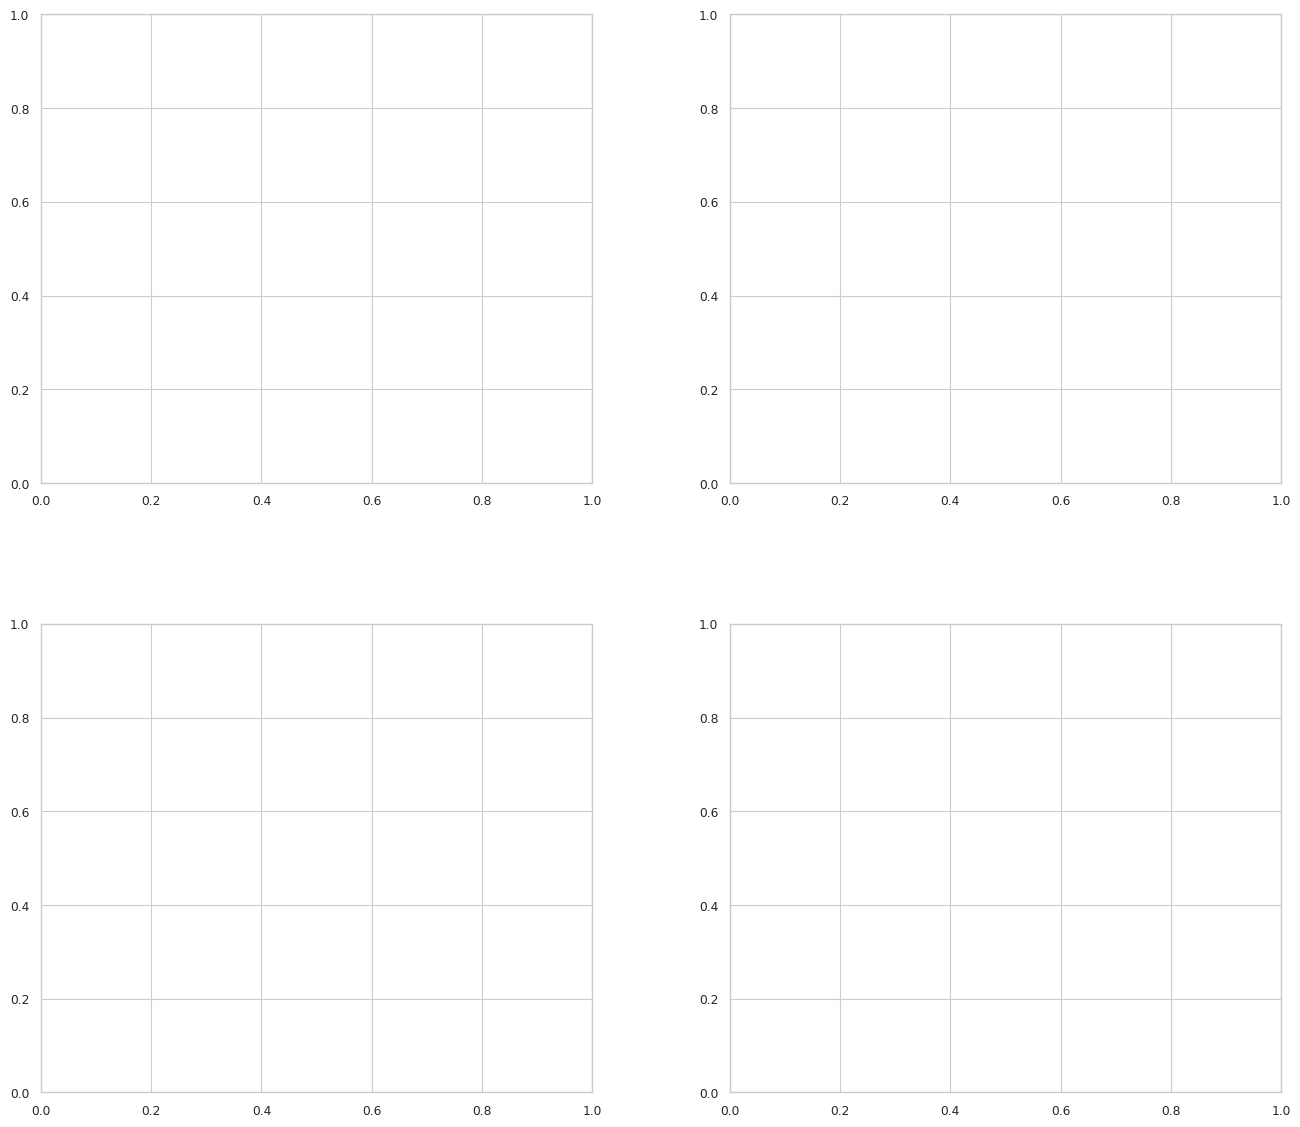

In [ ]:
#@title Generate Manuscript Figures (Log-Log Performance & Clusters)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Set plotting style
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# 1. ACTUAL VS PREDICTED (LOG-LOG SCALE)
# This is the most important plot for PBPK
ax1 = axes[0, 0]
eps = 1e-4 # Minimum floor for log plotting
ax1.scatter(analysis_export['fu_true']+eps, analysis_export['pred_fu']+eps,
            c=analysis_export['logP'], cmap='viridis', alpha=0.6, edgecolors='w', s=80)
ax1.plot([eps, 1], [eps, 1], 'r--', lw=2, label='Identity Line')
# Add 2-fold and 3-fold error lines
ax1.plot([eps*2, 1], [eps, 0.5], 'k:', alpha=0.5, label='2-fold error')
ax1.plot([eps, 0.5], [eps*2, 1], 'k:', alpha=0.5)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title(f"A. Model Performance (Log-Log Scale)\nGlobal R²: {r2_score(y_raw, final_preds):.3f}", fontsize=14)
ax1.set_xlabel("Observed fu (Log Scale)")
ax1.set_ylabel("Predicted fu (Log Scale)")
ax1.legend()

# 2. UMAP APPLICABILITY DOMAIN
ax2 = axes[0, 1]
sns.scatterplot(data=analysis_export, x='UMAP_1', y='UMAP_2',
                hue='Cluster', style='Cluster', s=100, palette='Set2', ax=ax2)
ax2.set_title("B. UMAP Chemical Space Mapping\nIdentification of Applicability Domains", fontsize=14)

# 3. FEATURE IMPORTANCE (SENSITIVITY)
ax3 = axes[1, 0]
# Use the importance_df generated in your training cell
sns.barplot(data=importance_df, x='importance', y='feature', palette='magma', ax=ax3)
ax3.set_title("C. Feature Sensitivity Analysis\n(Permutation Importance)", fontsize=14)
ax3.set_xlabel("Decrease in Model Accuracy when Shuffled")

# 4. ERROR DISTRIBUTION BY CLUSTER (GMFE)
ax4 = axes[1, 1]
sns.boxplot(data=analysis_export, x='Cluster', y='Fold_Error', palette='Set2', ax=ax4)
ax4.set_yscale('log')
ax4.set_title("D. Prediction Fold-Error Distribution", fontsize=14)
ax4.set_ylabel("Fold Error (Ratio Scale)")

# Add GMFE text labels to the boxplot
for i, cluster in enumerate(analysis_export['Cluster'].unique()):
    subset = analysis_export[analysis_export['Cluster'] == cluster]
    gmfe = 10**(np.mean(np.log10(subset['Fold_Error'])))
    ax4.text(i, ax4.get_ylim()[1]*0.5, f"GMFE:\n{gmfe:.2f}",
             ha='center', weight='bold', color='black', bbox=dict(facecolor='white', alpha=0.5))

plt.savefig("PBPK_Manuscript_Figures.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figures generated and saved as 'PBPK_Manuscript_Figures.png'")

In [ ]:
#@title Generate Protein-Ligand Structural Figure
!pip install py3dmol
import py3Dmol
import json
from pathlib import Path

def generate_manuscript_pose(protein_id="Albumin", ligand_name=None):
    # Find the best result for the chosen protein
    if ligand_name:
        target_row = boltz_df[boltz_df['name'] == ligand_name].iloc[0]
    else:
        # Default to the highest pIC50 ligand
        target_row = boltz_df.sort_values(by=f'{protein_id}_pic50', ascending=False).iloc[0]

    l_name = target_row['name']
    pic50 = target_row[f'{protein_id}_pic50']

    # Load the specific JSON structure
    json_path = Path(f"boltz2_batch_outputs/{protein_id}.json")
    if not json_path.exists():
        print(f"File {json_path} not found. Ensure Boltz runner completed.")
        return

    with open(json_path, "r") as f:
        data = json.load(f)

    # Extract structure (Boltz-2 format)
    struct = data["structures"][0]
    model_data = struct["structure"]
    fmt = struct.get("format", "pdb")

    print(f"Visualizing {l_name} in {protein_id} (pIC50: {pic50:.2f})")

    view = py3Dmol.view(width=800, height=600)
    view.addModel(model_data, fmt)

    # Style: Protein as soft spectrum cartoon, Ligand as Magenta sticks
    view.setStyle({'cartoon': {'color': 'yellow', 'opacity': 0.8}})
    # Boltz usually labels the ligand as 'L1' or 'LIG'
    view.addStyle({'resn': 'L1'}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.3}})
    view.addStyle({'resn': 'LIG1'}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.3}})

    view.zoomTo({'resn': 'L1'}) # Focus on the binding pocket
    return view.show()

# Run for Albumin (The primary carrier)
generate_manuscript_pose(protein_id="Albumin")

Visualizing triflupromazine in Albumin (pIC50: 6.92)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
def generate_manuscript_pose(protein_id="Albumin", ligand_name=None):
    # Find the best result for the chosen protein
    if ligand_name:
        target_row = boltz_df[boltz_df['name'] == ligand_name].iloc[0]
    else:
        # Default to the highest pIC50 ligand
        target_row = boltz_df.sort_values(by=f'{protein_id}_pic50', ascending=False).iloc[0]

    l_name = target_row['name']
    pic50 = target_row[f'{protein_id}_pic50']

    # Load the specific JSON structure
    json_path = Path(f"boltz2_batch_outputs/{protein_id}.json")
    if not json_path.exists():
        print(f"File {json_path} not found. Ensure Boltz runner completed.")
        return

    with open(json_path, "r") as f:
        data = json.load(f)

    # Extract structure (Boltz-2 format)
    struct = data["structures"][0]
    model_data = struct["structure"]
    fmt = struct.get("format", "pdb")

    # --- NEW: SAVE TO MMCIF FILE ---
    output_filename = f"{protein_id}_structure.cif"
    with open(output_filename, "w") as f:
        f.write(model_data)
    print(f"Structure saved to: {output_filename}")
    # -------------------------------

    print(f"Visualizing {l_name} in {protein_id} (pIC50: {pic50:.2f})")

    view = py3Dmol.view(width=800, height=600)
    view.addModel(model_data, fmt)

    # Style: Protein as soft spectrum cartoon, Ligand as Magenta sticks
    view.setStyle({'cartoon': {'color': 'yellow', 'opacity': 0.8}})
    view.addStyle({'resn': 'L1'}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.3}})
    view.addStyle({'resn': 'LIG1'}, {'stick': {'colorscheme': 'magentaCarbon', 'radius': 0.3}})

    view.zoomTo({'resn': 'L1'})
    return view.show()

# Run for Albumin
generate_manuscript_pose(protein_id="Albumin")

Structure saved to: Albumin_structure.cif
Visualizing triflupromazine in Albumin (pIC50: 6.92)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.